## Notebook

In [1]:
%matplotlib inline

import os
import json
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import networkx as nx
from multiprocessing import Pool
from tqdm import tqdm
from pathlib import Path

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.manifold import TSNE

import k3d

In [6]:
# # Get CCF lookups
# from collections import defaultdict
# ccf_structures = pd.read_csv('/data/allen_mouse_ccf/annotation/adult_mouse_ccf_structures.csv')
# id_to_acronym = defaultdict(lambda: "NaN")
# id_to_acronym = id_to_acronym | ccf_structures.set_index('id')['acronym'].to_dict()
# acronym_to_id = {acronym: ccf_id for ccf_id, acronym in id_to_acronym.items()}
# id_to_parent = ccf_structures.set_index('id')['parent_structure_id'].to_dict()
# id_to_parent[None] = None # to account for out of bands points

In [3]:
import lc_reconstruction_analysis.utils as utils
import lc_reconstruction_analysis.dendritic as dendritic
import lc_reconstruction_analysis.clustering as clustering
import lc_reconstruction_analysis.axon as axon
import lc_reconstruction_analysis.correlation as correlation

DATA_DIR = Path("../data/LC_Snapshots")
BASE_DIR = Path("../data/")

In [4]:
# Get CCF lookups
from collections import defaultdict
ccf_structures = pd.read_csv(BASE_DIR.joinpath("allen_mouse_ccf/annotation/adult_mouse_ccf_structures.csv"))
id_to_acronym = defaultdict(lambda: "NaN")
id_to_acronym = id_to_acronym | ccf_structures.set_index('id')['acronym'].to_dict()
acronym_to_id = {acronym: ccf_id for ccf_id, acronym in id_to_acronym.items()}
id_to_path = ccf_structures.set_index("id")["structure_id_path"].to_dict()

In [7]:
# # Create pathing dictionaries to group children CCF levels
# # rois = ["CB","MY","P","MB","TH","HY","CNU","CTXsp","HPF","OLF","Isocortex","fiber tracts","VS","grv","retina"] # remove "fiber tracts","VS","grv","retina" later
# # rois = ["FRP","MOs","MOp","SSs","SSp","GU","VISC","AUD","VIS","ACAd","ACAv","PL","ILA","ORBl","ORBm","ORBvl","AI","AId","AIp","AIv","RSP","PTLp","TEa","PERI","ECT",
# #            "Isocortex","CNU","CB","MY","P","MB","TH","HY","STRd","STRv","CTXsp","sAMY","LSX","HPF","OLF","fiber tracts","VS","grv","retina"] # remove "fiber tracts","VS","grv","retina" later
# # rois = ["FRP","MO","SS","GU","VISC","AUD","VIS","ACA","PL","ILA","ORB","AI","RSP","PTLp","TEa","PERI","ECT",
# #         "CB","MY","P","MB","TH","HY","CNU","CTXsp","HPF","OLF","fiber tracts","VS","grv","retina"]
# rois = ["FRP","MO","SS","GU","VISC","AUD","VIS","ACA","PL","ILA","ORB","AI","RSP","PTLp","TEa","PERI","ECT",
#         "LING","CENT","CUL","DEC","FOTU","PYR","UVU","NOD","SIM","AN","PRM","COPY","PFL","FL",
#         "MY","P","MB","TH","HY","CNU","CTXsp","HPF","OLF","fiber tracts","VS","grv","retina"]
# roiIDs = [acronym_to_id[roi] for roi in rois]
# # ctxRoiIDs = [acronym_to_id[roi] for roi in ctxRois]

# # Get the pathing for each leaf node, find which roi each belongs to
# id_to_path = ccf_structures.set_index("id")["structure_id_path"].to_dict()
# # Create a new dictionary corresponding each CCF copartment to matching ROI
# # id_to_roi = {}
# id_to_roi = defaultdict(lambda: np.nan)
# # For each CCF compartment, break down path and find matching ROI
# for key, val in id_to_path.items():
#     # Break down path 
#     pathList = [int(struct) for struct in val.split("/") if struct]
#     # Find matching ROI (should be empty, or a single element)
#     roiList = [id for id in roiIDs if id in pathList]
#     if not roiList:
#         id_to_roi[key] = np.nan
#     else:
#         id_to_roi[key] = roiList[0]

# # To check which values are uanccounted for
# # [id_to_acronym[struct] for struct in [key for key, val in id_to_roi.items() if np.isnan(val)]]

In [5]:
dataDF, graphs = utils.load_cells(DATA_DIR)

In [6]:
# Build length dataframe
lengthDF = clustering.build_length_df(dataDF,graphs,BASE_DIR,normalize_df=False)

In [7]:
# Get basic features, e.g. branching and length
axon_branch_dict = {}
dend_branch_dict = {}
dend_length_dict = {}
for name in dataDF["Graph"]:
    graph = graphs[name]
    # Get axonal branches
    axon_branch_nodes = [node for node in graph.nodes() if graph.out_degree(node) > 1 and graph.nodes[node]["structure_id"] == 2]
    axon_branch_dict[name] = len(axon_branch_nodes)
    # Get dendritic branches
    dend_branch_nodes = [node for node in graph.nodes() if graph.out_degree(node) > 1 and graph.nodes[node]["structure_id"] == 3] # get dendritic branches
    dend_branch_dict[name] = len(dend_branch_nodes)
    # Get dendritic lengths
    dend_graph = graph.subgraph([node for node in graph.nodes() if (graph.nodes[node]["structure_id"] == 3) or (graph.nodes[node]["structure_id"] == 1)])
    dend_length_dict[name] = sum(dend_graph[u][v]["weight"] for u, v in dend_graph.edges) # total length

# Combine length and branching into one dataframe
metricsDF = pd.concat([pd.Series(lengthDF.sum(axis=1) / 10000, name = "Axon Length (cm)"),
            pd.Series(axon_branch_dict, name = "Axon Branches"), 
            pd.Series(dend_length_dict, name = "Dendrite Length (cm)") / 10000,
            pd.Series(dend_branch_dict, name = "Dendrite Branches")], axis = 1)

In [8]:
# Merge dataframes
featureDF = pd.merge(dataDF,metricsDF,left_on="Graph", right_index=True, how = "left")

In [9]:
dataDF.head(3)

,Graph,ID,Sample,Genotype,somaAP,somaDV,somaML,Annotator 1,Annotator 2,Time to Trace (hrs),Assigned Type,Segmentation Version,Horta Coordinates,completeSC,isSpinalProjecting,somaOnRight
0,N001-685221,N001,685221,Dbh-Cre-KI/wt,10202.0168,4566.1902,4615.2926,Peter Grotz,NaN,5.00,Manual,NaN,"[30653.025, 10237.441, 10963.573]",False,True,False
1,N001-685222,N001,685222,Dbh-Cre-KI/wt,10354.5091,4146.1759,4725.1551,Shirali Amin,NaN,112.25,Manual,NaN,"[15834.622, 10044.901, 15855.611]",False,False,True
2,N001-721332,N001,721332,Dbh-Cre-KI/wt,10218.8658,4482.6014,4520.9614,Himani Parmar,NaN,44.20,Manual,NaN,"[14647.056, 16019.844, 12520.976]",True,True,False


## Comparisons to Mouselight

In [10]:
# Projection regions to look at
sorted_rois = ["OLF","Isocortex","HPF","CTXsp","CNU","TH","HY","MB","CB","P","MY","Other"]

In [11]:
# Build length dataframe
lengthDF = clustering.build_length_df(dataDF,graphs,BASE_DIR,normalize_df=False)

In [12]:
# Get basic features, e.g. branching and length
axon_branch_dict = {}
dend_branch_dict = {}
dend_length_dict = {}
for name in dataDF["Graph"]:
    graph = graphs[name]
    # Get axonal branches
    axon_branch_nodes = [node for node in graph.nodes() if graph.out_degree(node) > 1 and graph.nodes[node]["structure_id"] == 2]
    axon_branch_dict[name] = len(axon_branch_nodes)
    # Get dendritic branches
    dend_branch_nodes = [node for node in graph.nodes() if graph.out_degree(node) > 1 and graph.nodes[node]["structure_id"] == 3] # get dendritic branches
    dend_branch_dict[name] = len(dend_branch_nodes)
    # Get dendritic lengths
    dend_graph = graph.subgraph([node for node in graph.nodes() if (graph.nodes[node]["structure_id"] == 3) or (graph.nodes[node]["structure_id"] == 1)])
    dend_length_dict[name] = sum(dend_graph[u][v]["weight"] for u, v in dend_graph.edges) # total length

# Combine length and branching into one dataframe
metricsDF = pd.concat([pd.Series(lengthDF.sum(axis=1) / 10000, name = "Axon Length (cm)"),
            pd.Series(axon_branch_dict, name = "Axon Branches"), 
            pd.Series(dend_length_dict, name = "Dendrite Length (cm)") / 10000,
            pd.Series(dend_branch_dict, name = "Dendrite Branches")], axis = 1)

In [13]:
# Merge dataframes
featureDF = pd.merge(dataDF,metricsDF,left_on="Graph", right_index=True, how = "left")

In [14]:
# Get normalized features
normDF = pd.concat([lengthDF.divide(lengthDF.sum(axis = 1), axis = 0)[sorted_rois],
                    pd.Series(metricsDF["Axon Length (cm)"] / metricsDF["Axon Length (cm)"].max(), name = "Norm Axon Length"),
                    pd.Series(metricsDF["Axon Branches"] / metricsDF["Axon Branches"].max(), name = "Norm Axon Branches"),
                    pd.Series(metricsDF["Dendrite Length (cm)"] / metricsDF["Dendrite Length (cm)"].max(), name = "Norm Dend Length"),
                    pd.Series(metricsDF["Dendrite Branches"] / metricsDF["Dendrite Branches"].max(), name = "Norm Dend Branches")], axis = 1)

In [15]:
# Merge dataframes
fullDF = pd.merge(featureDF,normDF,left_on="Graph", right_index=True, how = "left")
fullDF["Most Length"] = [sorted_rois[i] for i in np.argmax(fullDF[sorted_rois],axis=1)] # Add top projection target
fullDF.head(3)

,Graph,ID,Sample,Genotype,somaAP,somaDV,somaML,Annotator 1,Annotator 2,Time to Trace (hrs),...,MB,CB,P,MY,Other,Norm Axon Length,Norm Axon Branches,Norm Dend Length,Norm Dend Branches,Most Length
0,N001-685221,N001,685221,Dbh-Cre-KI/wt,10202.0168,4566.1902,4615.2926,Peter Grotz,NaN,5.00,...,0.249435,0.000000,0.065383,0.345764,0.177100,0.174227,0.067057,0.474137,0.148936,MY
1,N001-685222,N001,685222,Dbh-Cre-KI/wt,10354.5091,4146.1759,4725.1551,Shirali Amin,NaN,112.25,...,0.039891,0.007071,0.004703,0.000000,0.009329,1.000000,0.639323,0.451131,0.276596,Isocortex
2,N001-721332,N001,721332,Dbh-Cre-KI/wt,10218.8658,4482.6014,4520.9614,Himani Parmar,NaN,44.20,...,0.006268,0.000000,0.030039,0.153646,0.787528,0.306572,0.190755,0.538732,0.212766,Other


### Get MouseLight neurons

In [16]:
## Compare to general population of moprhologies via MouseLight cells
folderPath = BASE_DIR.joinpath("mouselight_public")
filePaths = [os.path.join(folderPath,fn) for fn in os.listdir(folderPath) if fn.endswith(".json")]
# Load graphs
ml_graphs = utils.load_graphs(filePaths)
# Initiate dataDF
i = 0
datasetDicts = {}
for key, val in ml_graphs.items():
    try:
        soma = [
            node
            for node in val.nodes()
            if val.nodes[node]["structure_id"] == 1
        ]  # Get soma nodes
        assert len(soma) == 1
        x, y, z = val.nodes[soma[0]]["pos"]
    except Exception:
        print(
            f"Error finding structures for: {key}, dropping from dataframe"
        )
        continue
    neuronDict = {
        "Graph": key,
        "somaAP": x,
        "somaDV": y,
        "somaML": z,
    }
    datasetDicts[i] = neuronDict
    i = i + 1

# Assemble dataframe
ml_dataDF = pd.DataFrame.from_dict(datasetDicts, orient="index")

In [17]:
# Get axonal lengths
ml_lengthDF = clustering.build_length_df(ml_dataDF, ml_graphs, BASE_DIR, normalize_df=False)

# Get axon branching
ml_axon_branch_dict = {}
for name in ml_dataDF["Graph"]:
    graph = ml_graphs[name]
    axon_branch_nodes = [node for node in graph.nodes() if graph.out_degree(node) > 1 and graph.nodes[node]["structure_id"] == 2]
    ml_axon_branch_dict[name] = len(axon_branch_nodes)

# Combine length and branching into one dataframe
ml_featureDF = pd.DataFrame([pd.Series(ml_lengthDF.sum(axis=1) / 10000, name = "Axon Length (cm)"), 
                             pd.Series(ml_axon_branch_dict, name = "Axon Branches")]).T
ml_featureDF.head(3)

,Axon Length (cm),Axon Branches
AA0015,6.495602,258.0
AA0330,9.840050,118.0
AA0051,11.669337,265.0


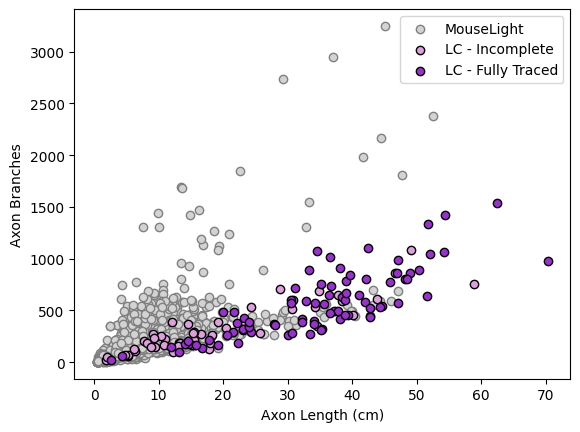

In [18]:
# Plot axon length vs branching
# Neurons with spinal cord projections from brains that do not have complete spinal cord may be incomplete.
incompleteMorphology = featureDF["isSpinalProjecting"] & ~featureDF["completeSC"]

plt.figure()

# Plot Mouselight data for reference
sns.scatterplot(ml_featureDF,x = "Axon Length (cm)", y = "Axon Branches", edgecolor = "gray", facecolor = "lightgray", linewidth = 1)

# Plot LC reconstructions
sns.scatterplot(featureDF[incompleteMorphology],x = "Axon Length (cm)", y = "Axon Branches", edgecolor = "black", facecolor = "Plum", linewidth = 1)
sns.scatterplot(featureDF[~incompleteMorphology],x = "Axon Length (cm)", y = "Axon Branches", edgecolor = "black", facecolor = "DarkOrchid", linewidth = 1)
plt.legend(["MouseLight","LC - Incomplete","LC - Fully Traced"])

# # Add regression lines
# sns.regplot(ml_featureDF,x = "Axon Length (cm)", y = "Axon Branches", color = "black", scatter = False)
# sns.regplot(featureDF,x = "Axon Length (cm)", y = "Axon Branches", color = "DarkOrchid", scatter = False)
plt.savefig(f"../results/LC and Mouselight length vs branch count.svg",dpi=300,bbox_inches='tight')

### Try regions of interest

In [20]:
# # Get list of unique regions
# region_lengths = {}
# lengthDict = {}

# trim_df = False
# normalize_df = True

# for i, graph in graphs.items():
#     # Assemble all nodes and edges
#     nodes = graph.nodes(data=True)
#     edges = graph.edges()
        
#     regions = {node['allen_id'] for _, node in nodes}
#     region_lengths = {}
#     # For each region, sum edge weights
#     for region in regions:
#         # Filter nodes in the given region
#         nodes_in_region = {i for i, node in nodes if node['allen_id'] == region and node["structure_id"] == 2}
    
#         # Include edges where at least one node is in the region
#         edges_in_region = [(u, v) for u, v in edges if u in nodes_in_region or v in nodes_in_region]
    
#         # Calculate the total length of edges within the region
#         total_length = sum(graph[u][v]['weight'] for u, v in edges_in_region)
    
#         # Store the result in the dictionary
#         region_lengths[region] = total_length
        
#     # Sum length within regions of interest
#     roi_lengths = defaultdict(np.float64)
#     for key, val in region_lengths.items():
#         roi_lengths[id_to_roi[key]] += val
                
#     lengthDict[i] = {id_to_acronym[key]: val for key, val in roi_lengths.items()}

# # Convert to dataframe
# dfLengths = pd.DataFrame.from_dict(lengthDict, orient='index').fillna(0)
# dfLengths.rename(columns={'NaN': 'Other'}, inplace=True) # Rename "NaN" to "Other"

# if trim_df:
#     total_counts = dfLengths.sum(axis=0, numeric_only=True)
#     cumsum = total_counts / sum(total_counts)
#     # set a threshold of a structure contributing at least 0.05% of total length
#     keep_cols = pd.concat([cumsum > 0.0005]) # add back in non-numeric columns
#     keep_cols["NaN"] = False # enforce removal of "NaN"
#     dfLengths = dfLengths.loc[:,keep_cols]


# if normalize_df:
#     # Try convert to z-scores
#     # dfLengths = (dfLengths - dfLengths.mean()) / dfLengths.std()

#     # Try normalizing to maximum in each column
#     # dfLengths = dfLengths / dfLengths.max()

#     # Try normalizing to axonal length within a cell
#     dfLengths = dfLengths.divide(dfLengths.sum(axis=1),axis=0)

#     # dfLengths = dfLengths.divide(dfLengths.sum(axis=1, numeric_only=True),axis=0)


In [21]:
# dfCtxLengths = dfLengths.copy()

In [13]:
# Convert to dataframe
dfLengths = pd.DataFrame.from_dict(lengthDict, orient='index').fillna(0)
dfLengths.rename(columns={'NaN': 'Other'}, inplace=True) # Rename "NaN" to "Other"
# Get just cortical areas
ctxROIs = ["FRP","MO","SS","GU","VISC","AUD","VIS","ACA","PL","ILA","ORB","AI","RSP","PTLp","TEa","PERI","ECT"]
dfLengths = dfLengths[ctxROIs] # Reorder the DataFrame based on sorted column names
dfLengths.head(5)

,FRP,MO,SS,GU,VISC,AUD,VIS,ACA,PL,ILA,ORB,AI,RSP,PTLp,TEa,PERI,ECT
N001-685221-PG,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,372.368422,0.000000,0.000000,0.000000,0.000000
N010-685221-VM,0.00000,11309.048193,32552.855076,9414.834704,9202.004879,4531.873432,1316.974547,0.000000,0.000000,607.862806,5069.897014,37176.159303,0.000000,0.000000,7014.543302,3238.815799,1925.073128
N005-685221-JN,2781.72804,100197.433381,86570.727562,274.985111,821.535249,10045.620622,16337.573330,19021.354135,12584.306738,6311.246492,18293.948822,1256.276032,25901.791419,9223.241003,3596.083385,235.303626,1889.533607
N012-685221-SA,0.00000,630.441748,16161.029404,7472.203569,3006.393365,0.000000,0.000000,54.590594,0.000000,0.000000,1143.243984,11004.111214,46.835566,0.000000,0.000000,0.000000,254.179685
N007-685221-BP,0.00000,0.000000,2241.265136,0.000000,536.800725,9952.627807,1439.324774,0.000000,0.000000,0.000000,0.000000,2302.361146,0.000000,0.000000,3514.495712,2067.125954,3852.913333


In [14]:
# Convert to dataframe
dfLengths = pd.DataFrame.from_dict(lengthDict, orient='index').fillna(0)
dfLengths.rename(columns={'NaN': 'Other'}, inplace=True) # Rename "NaN" to "Other"
# Get just cortical areas
ctxROIs = ["FRP","MO","SS","GU","VISC","AUD","VIS","ACA","PL","ILA","ORB","AI","RSP","PTLp","TEa","PERI","ECT"]
cbROIs = ["LING","CENT","CUL","DEC","FOTU","PYR","UVU","NOD","SIM","AN","PRM","COPY","PFL","FL"]
dfLengths = dfLengths[ctxROIs + cbROIs] # Reorder the DataFrame based on sorted column names
dfLengths.head(5)

,FRP,MO,SS,GU,VISC,AUD,VIS,ACA,PL,ILA,...,FOTU,PYR,UVU,NOD,SIM,AN,PRM,COPY,PFL,FL
N001-685221-PG,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
N010-685221-VM,0.00000,11309.048193,32552.855076,9414.834704,9202.004879,4531.873432,1316.974547,0.000000,0.000000,607.862806,...,0.0,138.841002,841.104936,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
N005-685221-JN,2781.72804,100197.433381,86570.727562,274.985111,821.535249,10045.620622,16337.573330,19021.354135,12584.306738,6311.246492,...,0.0,0.000000,0.000000,0.0,163.114213,0.000000,0.000000,0.000000,0.000000,0.0
N012-685221-SA,0.00000,630.441748,16161.029404,7472.203569,3006.393365,0.000000,0.000000,54.590594,0.000000,0.000000,...,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
N007-685221-BP,0.00000,0.000000,2241.265136,0.000000,536.800725,9952.627807,1439.324774,0.000000,0.000000,0.000000,...,0.0,0.000000,0.000000,0.0,492.101249,25121.964225,142.687897,36.736442,4535.764637,0.0


#### other

In [15]:
dfCtxCBProj = dfLengths[dfLengths.sum(axis = 1) > 0]
dfCtxCBProj.shape

(111, 31)

In [16]:
dfCtxProj = dfLengths[dfLengths.sum(axis = 1) > 0]
dfCtxProj.shape

(111, 31)

In [17]:
a = dataDF.copy()
b = dfCtxProj.divide(dfCtxProj.sum(axis=1),axis=0).copy()
plotDF = a.merge(b, left_on="Graph", right_index=True)
# plotDF = plotDF.set_index("Graph").join(pd.DataFrame.from_dict({key : sum(val.values()) for key, val in lengthDict.items()}, orient = "index", columns=["Total Length"])).reset_index()

In [19]:
# plotDF.sort_values("somaDV",ascending=False)

In [242]:
dfCtxAndCBProj = dfLengths[(dfLengths[ctxROIs].sum(axis = 1) > 0) & (dfLengths[cbROIs].sum(axis = 1) > 0) ]
dfCtxAndCBProj.shape

(36, 31)

In [273]:
dfCtxAndCBProj[(dfLengths["SIM"] > 0) & (dfLengths["AUD"] > 0) ].index

/tmp/ipykernel_436/2921700425.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  dfCtxAndCBProj[(dfLengths["SIM"] > 0) & (dfLengths["AUD"] > 0) ].index


Index(['N007-685221-BP', 'N005-685221-JN', 'N016-685221-PG', 'N038-685221-HS',
       'N041-685221-JN', 'N048-685221-VM', 'N015-685221-HD', 'N049-685221-SP',
       'N023-648434-HD', 'N018-685221-DS', 'N037-685221-SP'],
      dtype='object')

In [20]:
# from scipy.stats import pearsonr

# def correlation_pvalues(df):
#     cols = df.columns
#     pval_matrix = pd.DataFrame(index=cols, columns=cols, dtype=float)

#     for col1 in cols:
#         for col2 in cols:
#             if col1 == col2:
#                 pval_matrix.loc[col1, col2] = 0.0
#             else:
#                 corr, pval = pearsonr(df[col1], df[col2])
#                 pval_matrix.loc[col1, col2] = pval
#     return pval_matrix



In [21]:
corrMatrix = dfCtxProj.corr(method = "pearson")
mask = np.triu(np.ones_like(corrMatrix, dtype=bool), k=1)

### Cortical Flatmap

In [22]:
import ccf_streamlines.projection as ccfproj
import matplotlib.cm as cm
import matplotlib.colors as mcolors

In [23]:
# Establish flatmap projection objects and get area boundaries
bf_boundary_finder = ccfproj.BoundaryFinder(
    projected_atlas_file="../scratch/flatmap_dorsal.nrrd",
    labels_file="../scratch/labelDescription_ITKSNAPColor.txt",
)


bf_right_boundaries = bf_boundary_finder.region_boundaries(
    hemisphere='right',
    view_space_for_other_hemisphere='flatmap_dorsal',
)

# # Setup projector object
# ccf_coord_proj = ccfproj.IsocortexCoordinateProjector(
#     projection_file="../scratch/flatmap_dorsal.h5",
#     surface_paths_file="../scratch/surface_paths_10_v3.h5",
#     closest_surface_voxel_reference_file="../scratch/closest_surface_voxel_lookup.h5"
# )

# # Get cortex mask
# showStructs = ["Isocortex"]
# roiMask = rsp.make_structure_mask([acronym_to_id[val] for val in showStructs])

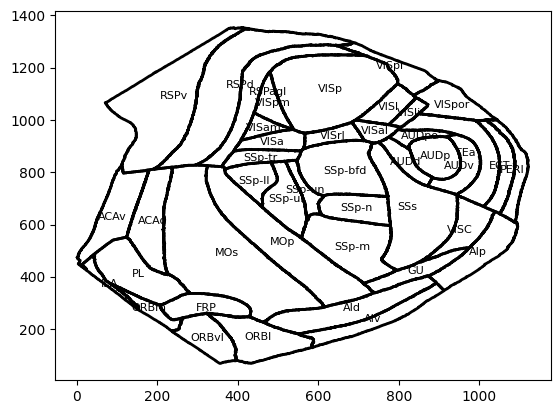

In [47]:
# for k, boundary_coords in bf_right_boundaries.items():
#     plt.plot(*boundary_coords.T, color = 'k', lw= 2)
#     plt.text(np.mean(boundary_coords[:,0]),np.mean(boundary_coords[:,1]),k, horizontalalignment = "center", verticalalignment = "center", fontsize = 8)

In [25]:
flatmapIDs = [acronym_to_id[roi] for roi in bf_right_boundaries.keys()]
# ctxRoiIDs = [acronym_to_id[roi] for roi in ctxRois]

# Get the pathing for each leaf node, find which roi each belongs to
id_to_flatmap_roi = defaultdict(lambda: np.nan)
# For each CCF compartment, break down path and find matching ROI
for key, val in id_to_path.items():
    # Break down path 
    pathList = [int(struct) for struct in val.split("/") if struct]
    # Find matching ROI (should be empty, or a single element)
    roiList = [id for id in flatmapIDs if id in pathList]
    if not roiList:
        id_to_flatmap_roi[key] = np.nan
    else:
        id_to_flatmap_roi[key] = roiList[0]

In [30]:
# # Map between finer resolution flatmap areas and measured length rois
# area_to_roi = {roi : id_to_acronym[id_to_roi[acronym_to_id[roi]]] for roi in bf_right_boundaries.keys()}

In [31]:
# # Normalize values
# dfRoiLengths = dfCtxProj.sum(axis=0)
# dfRoiLengths = dfRoiLengths / len(dfCtxProj) / 10000
# values = dfRoiLengths.values  # values to map to colors
# norm = mcolors.Normalize(vmin=0, vmax=values.max())  # Normalize values
# cmap = cm.viridis  # Choose the colormap

# # Make plot
# fig, ax = plt.subplots()

# for area, roi in area_to_roi.items():
#     boundary_coords = bf_right_boundaries[area]
#     color = cmap(norm(dfRoiLengths[area_to_roi[area]]))
#     plt.fill(*boundary_coords.T, color = color)
#     plt.plot(*boundary_coords.T, color = 'k', lw= 2)
#     plt.text(np.mean(boundary_coords[:,0]),np.mean(boundary_coords[:,1]),area, horizontalalignment = "center", verticalalignment = "center", fontsize = 8, color = 'gray')

# sm = cm.ScalarMappable(cmap=cmap, norm=norm)
# sm.set_array([])  # Needed only for colorbar
# plt.colorbar(sm, ax = ax, label='Length per neuron (cm)')

#### (Start here?) Recalculate lengths for finer resolution ROIs

In [27]:
flatmapIDs = [acronym_to_id[roi] for roi in bf_right_boundaries.keys()]
# ctxRoiIDs = [acronym_to_id[roi] for roi in ctxRois]

# Get the pathing for each leaf node, find which roi each belongs to
id_to_flatmap_roi = defaultdict(lambda: np.nan)
# For each CCF compartment, break down path and find matching ROI
for key, val in id_to_path.items():
    # Break down path 
    pathList = [int(struct) for struct in val.split("/") if struct]
    # Find matching ROI (should be empty, or a single element)
    roiList = [id for id in flatmapIDs if id in pathList]
    if not roiList:
        id_to_flatmap_roi[key] = np.nan
    else:
        id_to_flatmap_roi[key] = roiList[0]

In [28]:
# Get list of unique regions
region_lengths = {}
lengthDict = {}

trim_df = False
normalize_df = True

for i, graph in graphs.items():
    # Assemble all nodes and edges
    nodes = graph.nodes(data=True)
    edges = graph.edges()
        
    regions = {node['allen_id'] for _, node in nodes}
    region_lengths = {}
    # For each region, sum edge weights
    for region in regions:
        # Filter nodes in the given region
        nodes_in_region = {i for i, node in nodes if node['allen_id'] == region and node["structure_id"] == 2}
    
        # Include edges where at least one node is in the region
        edges_in_region = [(u, v) for u, v in edges if u in nodes_in_region or v in nodes_in_region]
    
        # Calculate the total length of edges within the region
        total_length = sum(graph[u][v]['weight'] for u, v in edges_in_region)
    
        # Store the result in the dictionary
        region_lengths[region] = total_length
        
    # Sum length within regions of interest
    roi_lengths = defaultdict(np.float64)
    for key, val in region_lengths.items():
        roi_lengths[id_to_flatmap_roi[key]] += val
                
    lengthDict[i] = {id_to_acronym[key]: val for key, val in roi_lengths.items()}

# Convert to dataframe
dfLengths = pd.DataFrame.from_dict(lengthDict, orient='index').fillna(0)
dfLengths.rename(columns={'NaN': 'Other'}, inplace=True) # Rename "NaN" to "Other"


if normalize_df:
    # Normalize to axonal length within a cell
    dfLengths = dfLengths.divide(dfLengths.sum(axis=1),axis=0)

In [29]:
# Convert to dataframe
dfLengths = pd.DataFrame.from_dict(lengthDict, orient='index').fillna(0)
dfLengths.rename(columns={'NaN': 'Other'}, inplace=True) # Rename "NaN" to "Other"
# Get just cortical areas
dfLengths = dfLengths[bf_right_boundaries.keys()] # Reorder the DataFrame based on sorted column names
dfCtxProj = dfLengths[dfLengths.sum(axis = 1) > 0]
dfCtxProj.head(3)

,ACAd,ACAv,AId,AIp,AIv,AUDd,AUDp,AUDpo,AUDv,ECT,...,VISam,VISC,VISl,VISp,VISpl,VISpm,VISa,VISli,VISpor,VISrl
N023-685221,0.000000,0.000000,12163.042712,9890.915711,4160.439623,5335.658412,9471.371837,2002.442691,2713.687543,2193.530989,...,0.000000,6610.300886,959.502331,0.000000,0.0,0.000000,0.000000,677.045023,0.0,0.00000
N041-685221,2777.031684,3062.004709,2064.857461,3654.315874,907.793484,407.663305,619.439564,1965.658777,0.000000,2462.397629,...,126.942229,0.000000,1577.445309,4181.610596,0.0,176.782239,2193.342692,968.783566,0.0,0.00000
N005-685221,16506.169724,1620.913589,515.464728,0.000000,658.856404,1731.505816,4118.726955,0.000000,3862.869391,1931.173585,...,1676.548471,747.206780,635.896996,8610.607949,0.0,4322.433421,6486.196056,0.000000,0.0,2338.90472


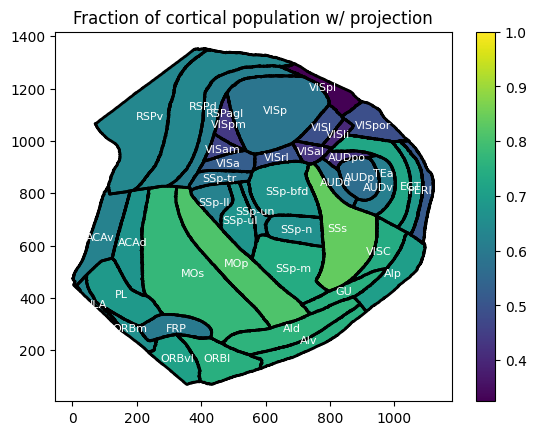

In [32]:
# Normalize values
values = np.sum(dfCtxProj > 0,axis=0) / len(dfCtxProj)  # values to map to colors
norm = mcolors.Normalize(vmin=values.min(), vmax=1)  # Normalize values
cmap = cm.viridis  # Choose the colormap

# Make plot
fig, ax = plt.subplots()

for area, boundary_coords in bf_right_boundaries.items():
    color = cmap(norm(values[area]))
    plt.fill(*boundary_coords.T, color = color)
    plt.plot(*boundary_coords.T, color = 'k', lw= 2)
    plt.text(np.mean(boundary_coords[:,0]),np.mean(boundary_coords[:,1]),area, horizontalalignment = "center", verticalalignment = "center", fontsize = 8, color = 'white')

sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # Needed only for colorbar
# plt.colorbar(sm, ax = ax, label='Fraction of cortical population')
plt.colorbar(sm, ax = ax)
plt.title("Fraction of cortical population w/ projection")
plt.savefig(f"../results/Fractional projections to cortical regions.svg",dpi=300,bbox_inches='tight',transparent=True)

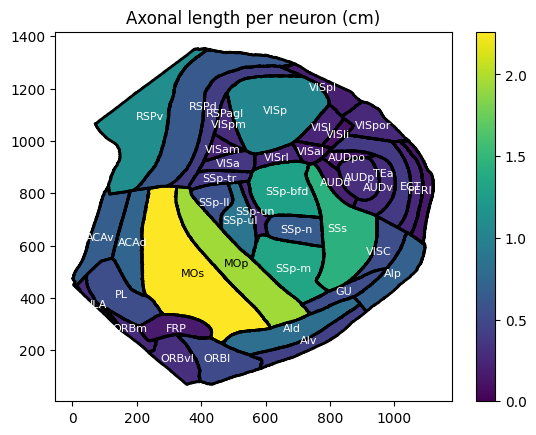

In [33]:
# Normalize values
dfRoiLengths = dfCtxProj[dfCtxProj != 0].mean(axis=0)
dfRoiLengths = dfRoiLengths / 1e4
values = dfRoiLengths.values  # values to map to colors
norm = mcolors.Normalize(vmin=0, vmax=values.max())  # Normalize values
cmap = cm.viridis  # Choose the colormap

# Make plot
fig, ax = plt.subplots()

for area, boundary_coords in bf_right_boundaries.items():
    color = cmap(norm(dfRoiLengths[area]))
    plt.fill(*boundary_coords.T, color = color)
    plt.plot(*boundary_coords.T, color = 'k', lw= 2)
    if norm(dfRoiLengths[area]) > .8:
        txtColor = 'black'
    else:
        txtColor = 'white'
    plt.text(np.mean(boundary_coords[:,0]),np.mean(boundary_coords[:,1]),area, horizontalalignment = "center", verticalalignment = "center", fontsize = 8, color = txtColor)

sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # Needed only for colorbar
# plt.colorbar(sm, ax = ax, label='Axonal length per neuron (cm)')
plt.colorbar(sm, ax = ax)
plt.title("Axonal length per neuron (cm)")
plt.savefig(f"../results/Axonal length per neuron (cm).svg",dpi=300,bbox_inches='tight',transparent=True)

In [34]:
def load_obj(filename):
    """
    Load the vertices, vertex normals, and indices from a .obj file.

    Parameters:
    filename (str): Path to the .obj file

    Returns:
    tuple: A tuple containing three elements:
        - vertices (list of tuples): List of vertices, each vertex is a tuple (x, y, z)
        - normals (list of tuples): List of vertex normals, each normal is a tuple (nx, ny, nz)
        - indices (list of tuples): List of indices, each index is a tuple of vertex indices defining a face
    """
    vertices = []
    normals = []
    indices = []

    with open(filename, 'r') as file:
        for line in file:
            if line.startswith('v '):  # Vertex definition
                parts = line.split()
                vertices.append((float(parts[1]), float(parts[2]), float(parts[3])))
            elif line.startswith('vn '):  # Vertex normal definition
                parts = line.split()
                normals.append((float(parts[1]), float(parts[2]), float(parts[3])))
            elif line.startswith('f '):  # Face definition
                parts = line.split()
                # Extracting only the vertex indices (ignoring texture and normal indices)
                face_indices = [int(p.split('/')[0]) - 1 for p in parts[1:]]
                indices.append(tuple(face_indices))

    return vertices, normals, indices

def get_mesh_from_id(allen_id):
    obj_dir = "../data/ccf_2017_obj"
    obj_path = os.path.join(obj_dir, f"{allen_id}.obj")
    return load_obj(obj_path)

def compute_mesh_volume(vertices, indices):
    volume = 0.0
    for tri in indices:  # Each `tri` is a list of 3 indices
        v1 = np.array(vertices[tri[0]])
        v2 = np.array(vertices[tri[1]])
        v3 = np.array(vertices[tri[2]])
        
        # Compute the signed volume of the tetrahedron
        tetra_volume = np.dot(v1, np.cross(v2, v3)) / 6.0
        volume += tetra_volume

    return abs(volume)  # Take absolute value to ensure positive volume

def compute_mesh_centroid(vertices, indices):
    # Convert inputs to numpy arrays if they aren't already
    vertices = np.array(vertices, dtype=float)
    indices = np.array(indices, dtype=int)

    total_area = 0.0
    weighted_centroid = np.zeros(3)

    for tri in indices:
        v0, v1, v2 = vertices[tri[0]], vertices[tri[1]], vertices[tri[2]]

        tri_centroid = (v0 + v1 + v2) / 3.0

        edge1 = v1 - v0
        edge2 = v2 - v0
        tri_area = np.linalg.norm(np.cross(edge1, edge2)) / 2.0

        weighted_centroid += tri_centroid * tri_area
        total_area += tri_area

    if total_area == 0:
        # Fallback to average of vertices if total area is zero
        return np.mean(vertices, axis=0)
    else:
        return weighted_centroid / total_area

In [35]:
# Functions below
volDict = {}
for name in bf_right_boundaries.keys():
    x = get_mesh_from_id(acronym_to_id[name])
    volDict[name] = compute_mesh_volume(x[0],x[2])

# Convert to a dataframe of cubic centimeters
roiVolumes = pd.Series(volDict) / 1e11

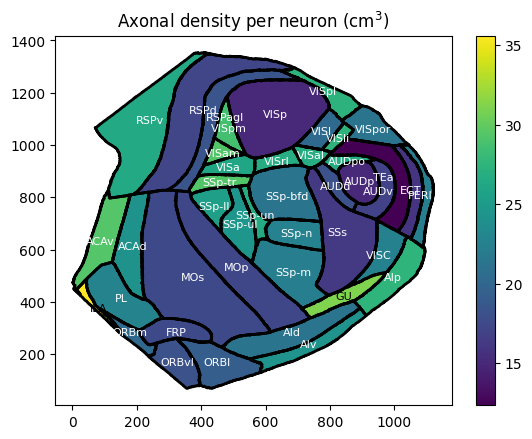

In [36]:
# Normalize values
dfRoiLengths = dfCtxProj[dfCtxProj != 0].mean(axis=0) / 1e4
dfRoiLengths = dfRoiLengths / roiVolumes
values = dfRoiLengths.values  # values to map to colors
norm = mcolors.Normalize(vmin=values.min(), vmax=values.max())  # Normalize values
cmap = cm.viridis  # Choose the colormap

# Make plot
fig, ax = plt.subplots()

for area, boundary_coords in bf_right_boundaries.items():
    color = cmap(norm(dfRoiLengths[area]))
    plt.fill(*boundary_coords.T, color = color)
    plt.plot(*boundary_coords.T, color = 'k', lw= 2)
    if norm(dfRoiLengths[area]) > .8:
        txtColor = 'black'
    else:
        txtColor = 'white'
    plt.text(np.mean(boundary_coords[:,0]),np.mean(boundary_coords[:,1]),area, horizontalalignment = "center", verticalalignment = "center", fontsize = 8, color = txtColor)

sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # Needed only for colorbar
# plt.colorbar(sm, ax = ax, label='Axonal length per neuron (cm)')
plt.colorbar(sm, ax = ax)
plt.title("Axonal density per neuron (cm$^3$)")
plt.savefig(f"../results/Axonal density per neuron (cubic cm).svg",dpi=300,bbox_inches='tight',transparent=True)

### Compute correlation matrices

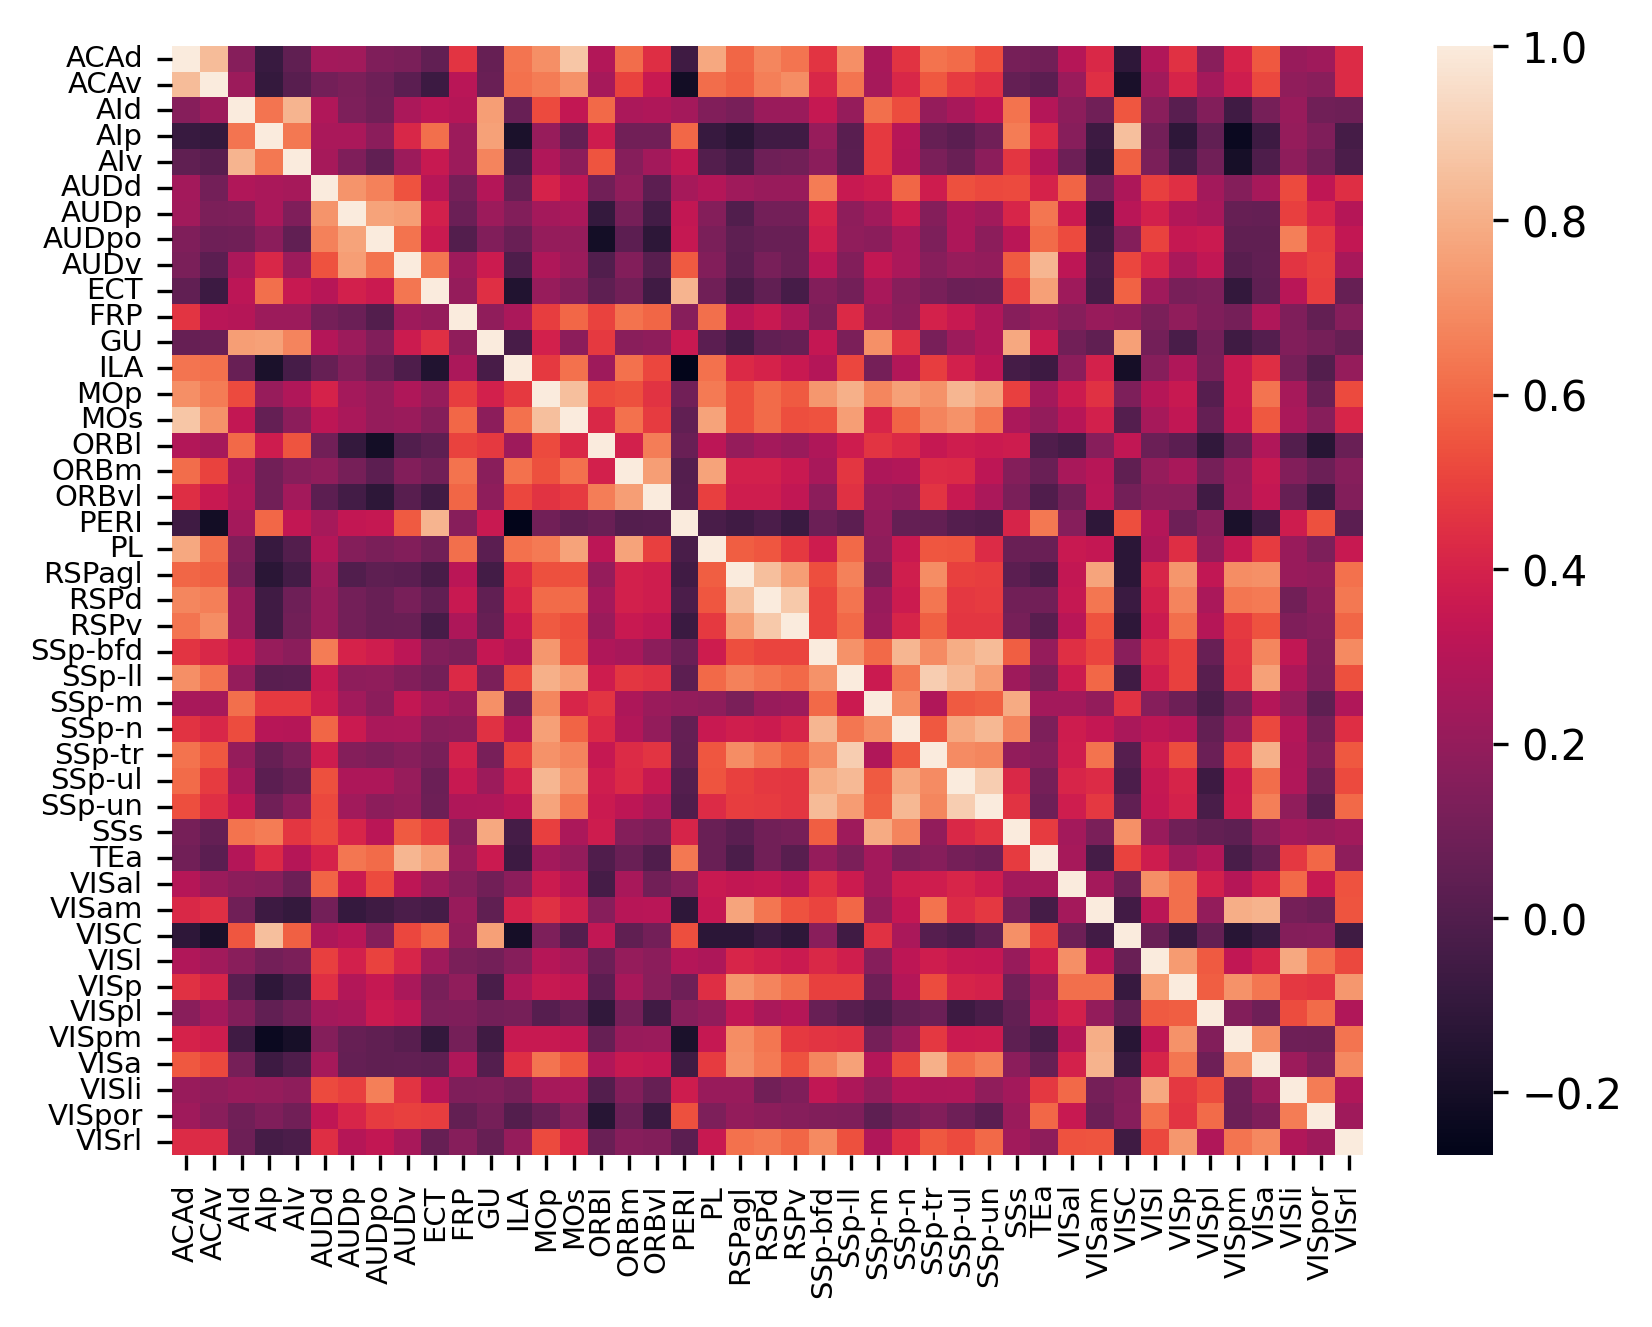

In [37]:
corrMatrix = dfCtxProj.corr(method = "spearman")
# mask = np.triu(np.ones_like(corrMatrix, dtype=bool), k=1)
plt.figure(dpi=300)
sns.heatmap(corrMatrix, xticklabels=True,yticklabels=True,  annot=False, fmt = '.2f', annot_kws={'size': 4})
plt.yticks(fontsize=7);
plt.xticks(fontsize=7);
plt.savefig(f"../results/Cortical correlation matrix (spearman, granular).svg",dpi=300,bbox_inches='tight',transparent=True)

In [38]:
# Functions below
centroidDict = {}
for name in bf_right_boundaries.keys():
    x = get_mesh_from_id(acronym_to_id[name])
    centroidDict[name] = compute_mesh_centroid(x[0],x[2])

# Convert to a dataframe of cubic centimeters
# roiVolumes = pd.Series(volDict) / 1e11

In [39]:
from itertools import combinations

In [40]:
pairs = []
distances = []
correlations = []

# Get all unique pairs of keys from the centroids (or corr_df)
keys = list(centroidDict.keys())

for key1, key2 in combinations(keys, 2):
    # Compute Euclidean distance between centroids
    c1 = np.array(centroidDict[key1])
    c2 = np.array(centroidDict[key2])
    dist = np.linalg.norm(c1 - c2)

    # Get correlation value from corr_df (assuming symmetric)
    corr_val = corrMatrix.loc[key1, key2]

    pairs.append((key1, key2))
    distances.append(dist)
    correlations.append(corr_val)

# Create DataFrame for plotting / analysis
dfCorrDist = pd.DataFrame({
    'pair': pairs,
    'distance': distances,
    'correlation': correlations
})

dfCorrDist["distance"] = dfCorrDist["distance"] / 1e3 # convert to mm

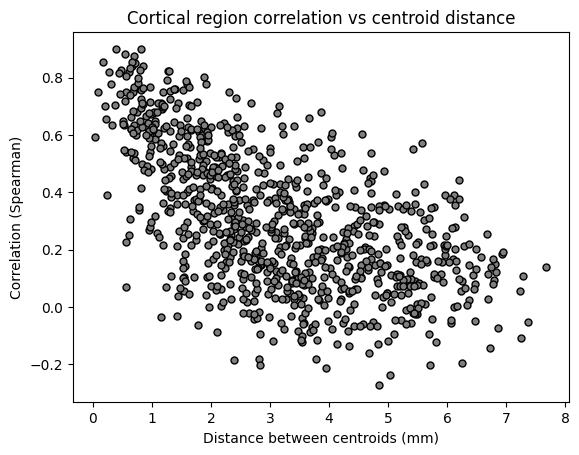

In [41]:
plt.plot(dfCorrDist['distance'], dfCorrDist['correlation'], 'o', markersize = 5, color = 'tab:gray', markeredgecolor = 'k')
plt.xlabel('Distance between centroids (mm)')
plt.ylabel('Correlation (Spearman)')
plt.title('Cortical region correlation vs centroid distance')
# plt.grid(True)
plt.savefig(f"../results/Correlation vs distance (spearman, granular).svg",dpi=300,bbox_inches='tight',transparent=True)

In [97]:
# # Normalize values
# feature = "RSPv"
# dfRoiLengths = corrMatrix[feature]
# values = dfRoiLengths.values  # values to map to colors
# norm = mcolors.Normalize(vmin=0, vmax=values.max())  # Normalize values
# cmap = cm.viridis  # Choose the colormap

# # Make plot
# fig, ax = plt.subplots()

# for area, boundary_coords in bf_right_boundaries.items():
#     color = cmap(norm(dfRoiLengths[area]))
#     plt.fill(*boundary_coords.T, color = color)
#     plt.plot(*boundary_coords.T, color = 'k', lw= 2)
#     if norm(dfRoiLengths[area]) > .8:
#         txtColor = 'black'
#     else:
#         txtColor = 'white'
#     plt.text(np.mean(boundary_coords[:,0]),np.mean(boundary_coords[:,1]),area, horizontalalignment = "center", verticalalignment = "center", fontsize = 8, color = txtColor)

# sm = cm.ScalarMappable(cmap=cmap, norm=norm)
# sm.set_array([])  # Needed only for colorbar
# # plt.colorbar(sm, ax = ax, label='Axonal length per neuron (cm)')
# plt.colorbar(sm, ax = ax)
# plt.title(f"Correlation (spearman) to {feature}")
# plt.savefig(f"../results/Correlation (spearman) to {feature}.svg",dpi=300,bbox_inches='tight',transparent=True)

<Figure size 640x480 with 0 Axes>

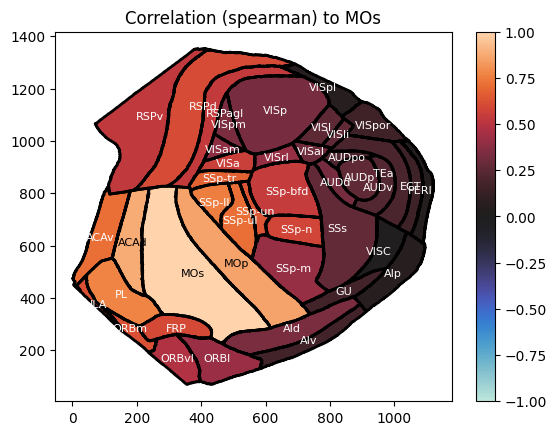

<Figure size 640x480 with 0 Axes>

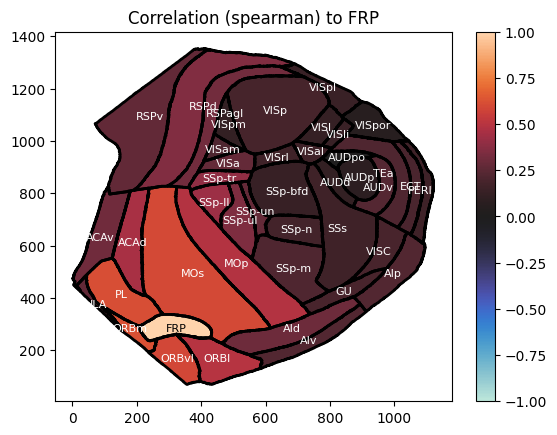

<Figure size 640x480 with 0 Axes>

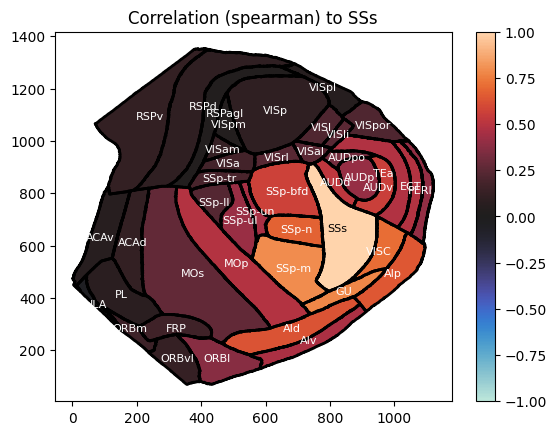

<Figure size 640x480 with 0 Axes>

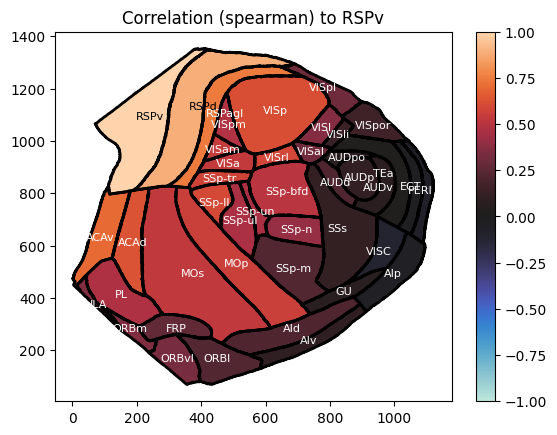

<Figure size 640x480 with 0 Axes>

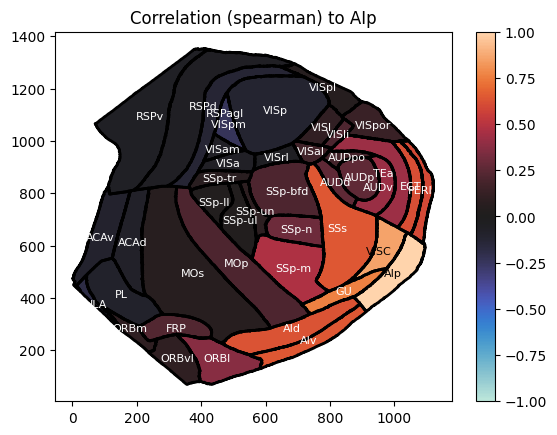

<Figure size 640x480 with 0 Axes>

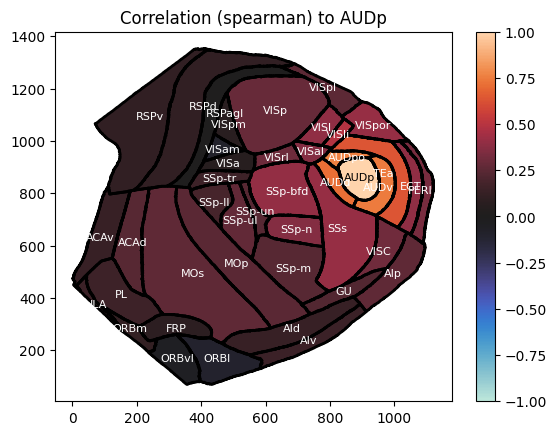

<Figure size 640x480 with 0 Axes>

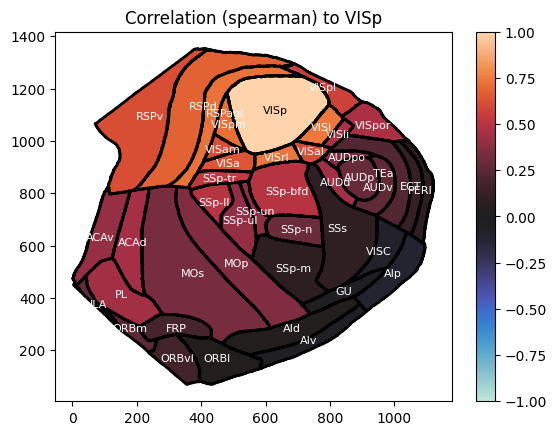

In [42]:
# Normalize values
featureList = ["MOs","FRP","SSs","RSPv","AIp","AUDp",'VISp']

for feature in featureList:
    plt.figure()
    dfRoiLengths = corrMatrix[feature]
    values = dfRoiLengths.values  # values to map to colors
    norm = mcolors.Normalize(vmin=-1, vmax=1)  # Normalize values
    # cmap = cm.coolwarm # Choose the colormap
    cmap = sns.color_palette("icefire", as_cmap=True)
    
    # Make plot
    fig, ax = plt.subplots()
    
    for area, boundary_coords in bf_right_boundaries.items():
        color = cmap(norm(dfRoiLengths[area]))
        plt.fill(*boundary_coords.T, color = color)
        plt.plot(*boundary_coords.T, color = 'k', lw= 2)
        if norm(dfRoiLengths[area]) > .9:
            txtColor = 'black'
        else:
            txtColor = 'white'
        plt.text(np.mean(boundary_coords[:,0]),np.mean(boundary_coords[:,1]),area, horizontalalignment = "center", verticalalignment = "center", fontsize = 8, color = txtColor)
    
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])  # Needed only for colorbar
    # plt.colorbar(sm, ax = ax, label='Axonal length per neuron (cm)')
    plt.colorbar(sm, ax = ax)
    plt.title(f"Correlation (spearman) to {feature}")
    plt.savefig(f"../results/Correlation (spearman) to {feature}.svg",dpi=300,bbox_inches='tight',transparent=True)

<Figure size 1920x1440 with 0 Axes>

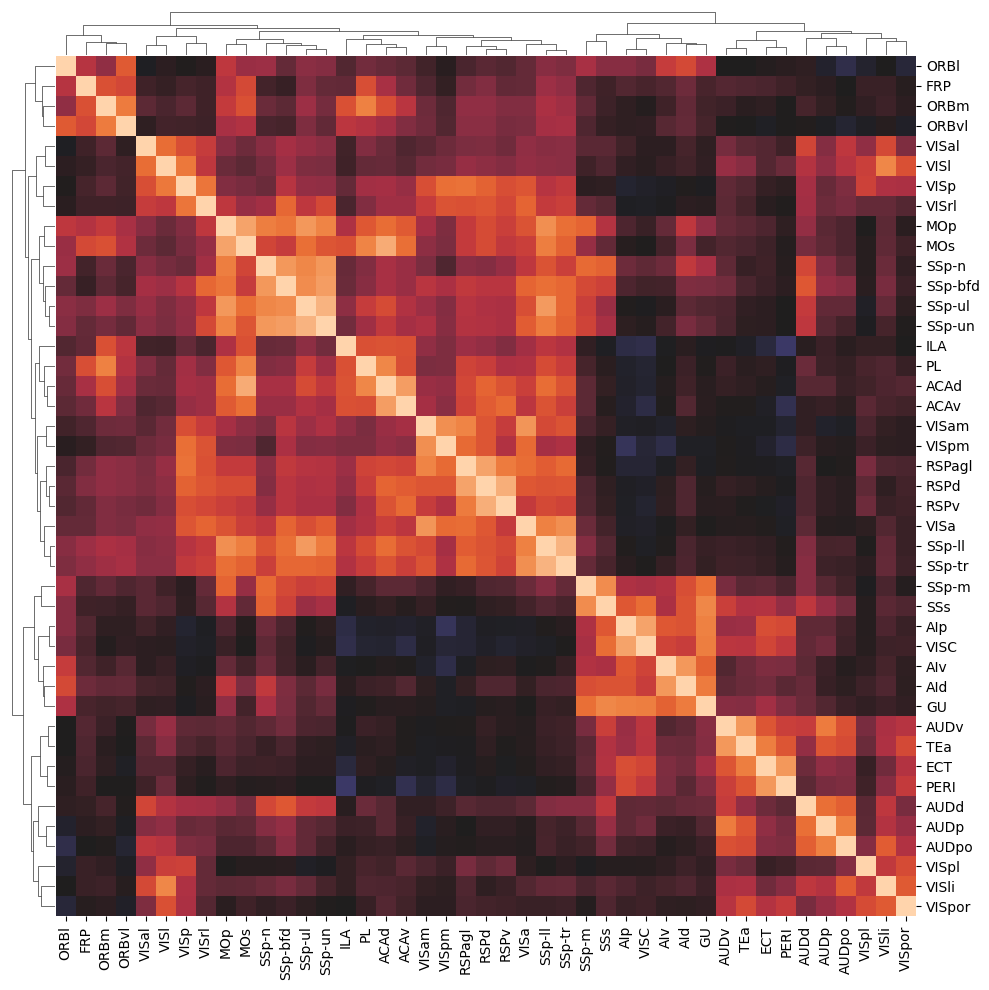

In [69]:
corrMatrix = dfCtxProj.corr(method = "spearman")
# mask = np.triu(np.ones_like(corrMatrix, dtype=bool), k=1)
plt.figure(dpi=300)
g = sns.clustermap(corrMatrix, xticklabels=True,yticklabels=True,  annot=False, fmt = '.2f', annot_kws={'size': 4}, cbar=False, dendrogram_ratio=.05, cmap = "icefire", center = 0, vmin = -1, vmax = 1)
# Remove colorbar axis completely if it still appears
if g.cax is not None:
    g.cax.set_visible(False)
plt.yticks(fontsize=7);
plt.xticks(fontsize=7);
plt.savefig(f"../results/Cortical clustermap (spearman, granular).svg",dpi=300,bbox_inches='tight',transparent=True)

#### Cross functional correlation

In [44]:
cbRois = ["LING","CENT","CUL","DEC","FOTU","PYR","UVU","NOD","SIM","AN","PRM","COPY","PFL","FL"]
cbAndCtxRois = list(bf_right_boundaries.keys()) + cbRois

In [45]:
cbAndCtxIDs = [acronym_to_id[roi] for roi in cbAndCtxRois]

# Get the pathing for each leaf node, find which roi each belongs to
id_to_roi = defaultdict(lambda: np.nan)
# For each CCF compartment, break down path and find matching ROI
for key, val in id_to_path.items():
    # Break down path 
    pathList = [int(struct) for struct in val.split("/") if struct]
    # Find matching ROI (should be empty, or a single element)
    roiList = [id for id in cbAndCtxIDs if id in pathList]
    if not roiList:
        id_to_roi[key] = np.nan
    else:
        id_to_roi[key] = roiList[0]

In [46]:
# Get list of unique regions
region_lengths = {}
lengthDict = {}

trim_df = False
normalize_df = True

for i, graph in graphs.items():
    # Assemble all nodes and edges
    nodes = graph.nodes(data=True)
    edges = graph.edges()
        
    regions = {node['allen_id'] for _, node in nodes}
    region_lengths = {}
    # For each region, sum edge weights
    for region in regions:
        # Filter nodes in the given region
        nodes_in_region = {i for i, node in nodes if node['allen_id'] == region and node["structure_id"] == 2}
    
        # Include edges where at least one node is in the region
        edges_in_region = [(u, v) for u, v in edges if u in nodes_in_region or v in nodes_in_region]
    
        # Calculate the total length of edges within the region
        total_length = sum(graph[u][v]['weight'] for u, v in edges_in_region)
    
        # Store the result in the dictionary
        region_lengths[region] = total_length
        
    # Sum length within regions of interest
    roi_lengths = defaultdict(np.float64)
    for key, val in region_lengths.items():
        roi_lengths[id_to_roi[key]] += val
                
    lengthDict[i] = {id_to_acronym[key]: val for key, val in roi_lengths.items()}

# Convert to dataframe
dfLengths = pd.DataFrame.from_dict(lengthDict, orient='index').fillna(0)
dfLengths.rename(columns={'NaN': 'Other'}, inplace=True) # Rename "NaN" to "Other"

if normalize_df:
    # Normalize to axonal length within a cell
    dfLengths = dfLengths.divide(dfLengths.sum(axis=1),axis=0)

In [58]:
# Convert to dataframe
dfLengths = pd.DataFrame.from_dict(lengthDict, orient='index').fillna(0)
dfLengths.rename(columns={'NaN': 'Other'}, inplace=True) # Rename "NaN" to "Other"
# Get just cortical areas
dfLengths = dfLengths[cbAndCtxRois] # Reorder the DataFrame based on sorted column names
# dfCbAndCtxProj = dfLengths[dfLengths.sum(axis = 1) > 0]
dfCbAndCtxProj = dfLengths
dfCbAndCtxProj.head(3)

,ACAd,ACAv,AId,AIp,AIv,AUDd,AUDp,AUDpo,AUDv,ECT,...,FOTU,PYR,UVU,NOD,SIM,AN,PRM,COPY,PFL,FL
N023-685221,0.000000,0.000000,12163.042712,9890.915711,4160.439623,5335.658412,9471.371837,2002.442691,2713.687543,2193.530989,...,0.000000,0.00000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0
N041-685221,2777.031684,3062.004709,2064.857461,3654.315874,907.793484,407.663305,619.439564,1965.658777,0.000000,2462.397629,...,3775.984628,2464.69494,3501.817368,0.0,582.285322,7842.162984,6579.048374,5894.098102,0.0,0.0
N005-685221,16506.169724,1620.913589,515.464728,0.000000,658.856404,1731.505816,4118.726955,0.000000,3862.869391,1931.173585,...,0.000000,0.00000,0.000000,0.0,151.075496,0.000000,0.000000,0.000000,0.0,0.0


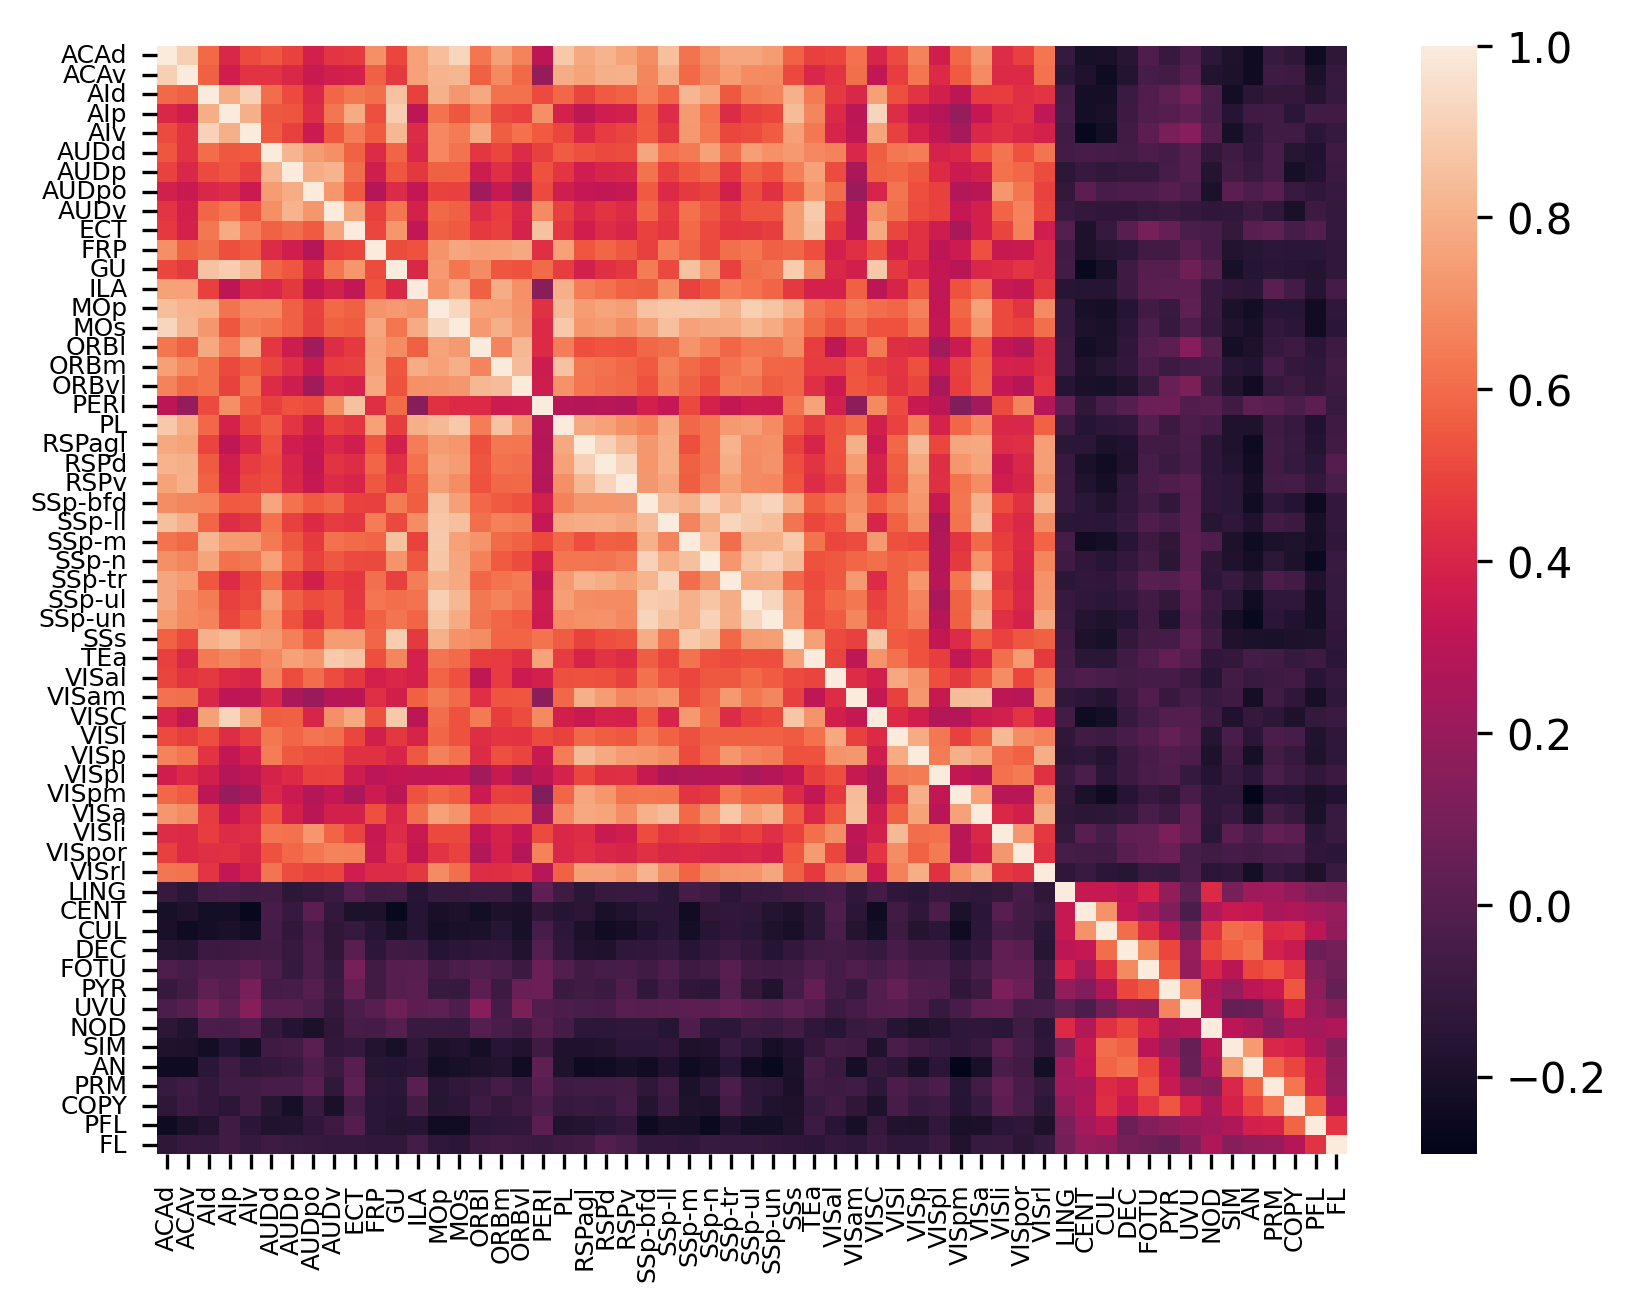

In [59]:
corrMatrix = dfCbAndCtxProj.corr(method = "spearman")
# mask = np.triu(np.ones_like(corrMatrix, dtype=bool), k=1)
plt.figure(dpi=300)
sns.heatmap(corrMatrix, xticklabels=True,yticklabels=True,  annot=False, fmt = '.2f', annot_kws={'size': 4})
plt.yticks(fontsize=6);
plt.xticks(fontsize=6);
# plt.title("Cortical and Cerebellar Correlation, all neurons")
plt.savefig(f"../results/Cortical and cerebellar correlation matrix (spearman, granular, all neurons).svg",dpi=300,bbox_inches='tight',transparent=True)

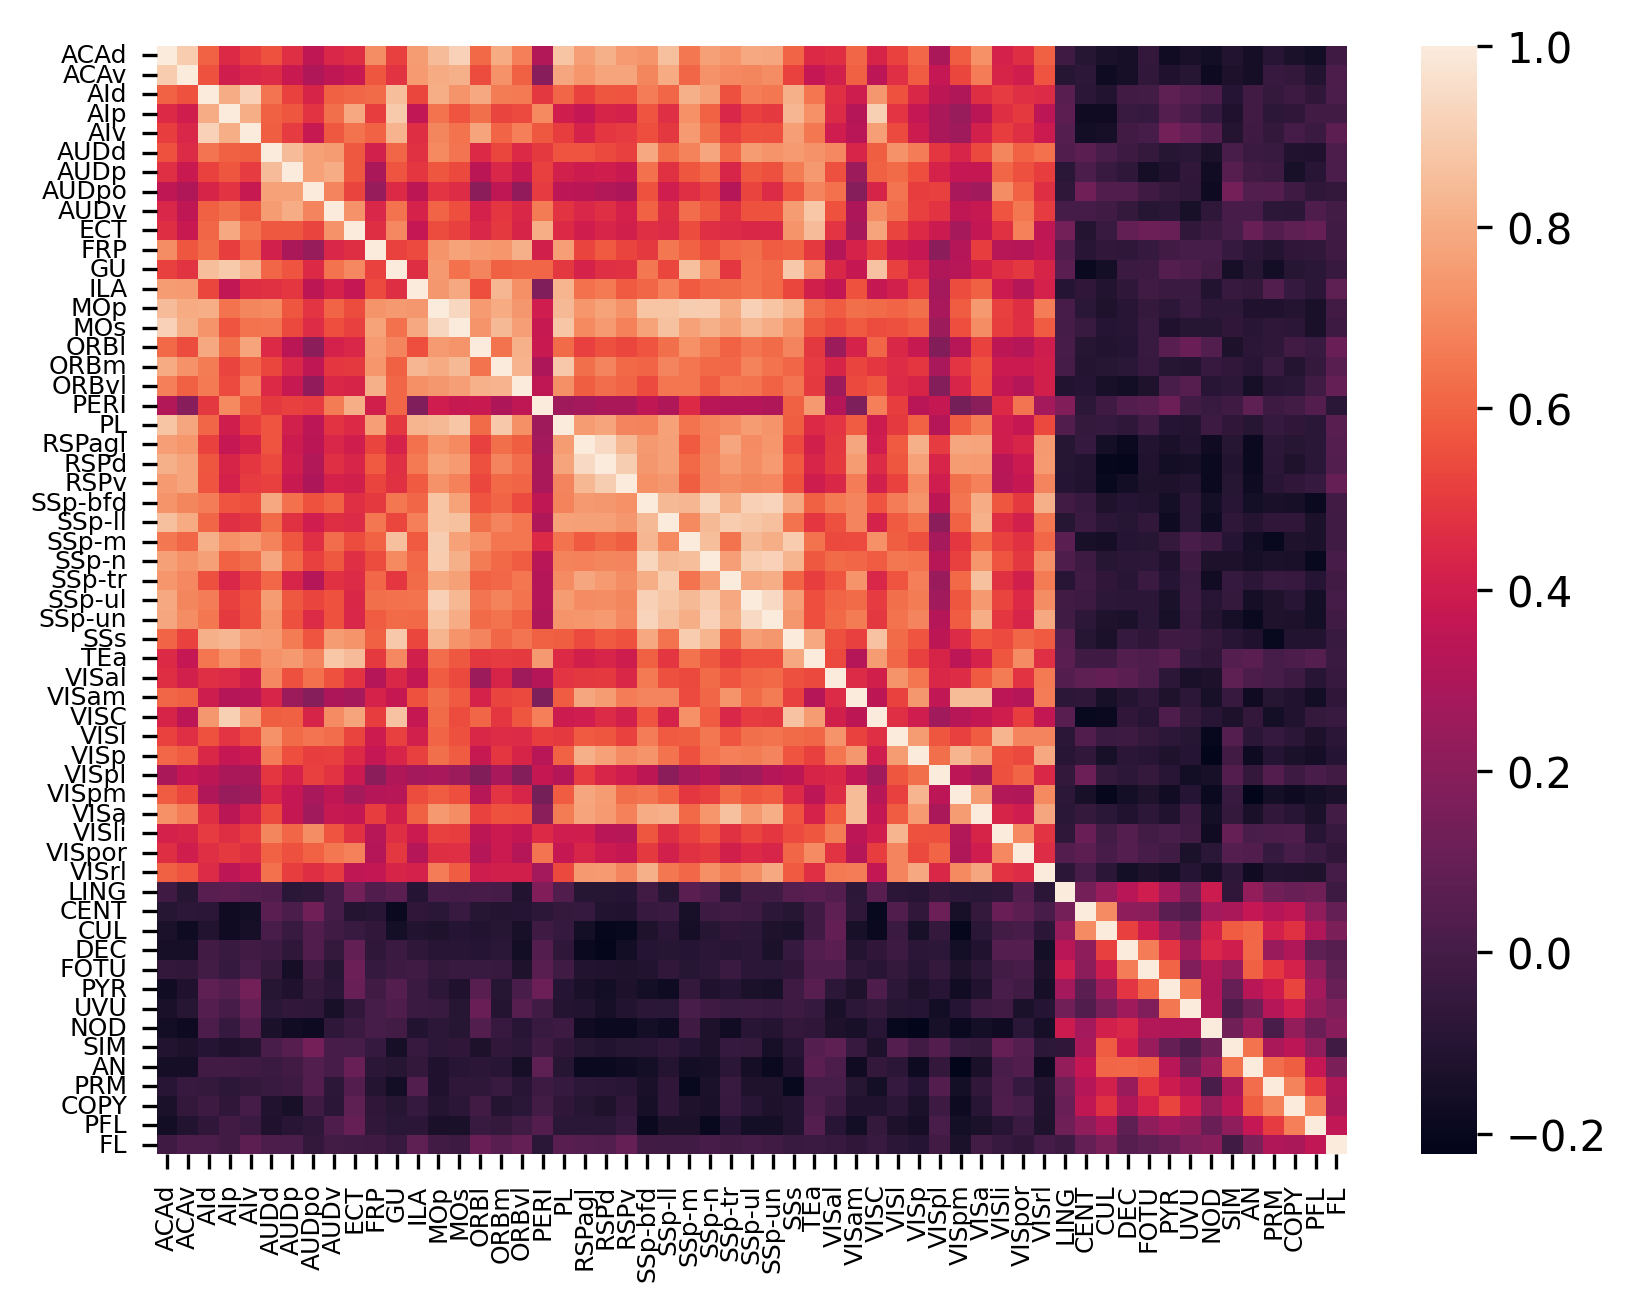

In [394]:
corrMatrix = dfCbAndCtxProj.corr(method = "spearman")
# mask = np.triu(np.ones_like(corrMatrix, dtype=bool), k=1)
plt.figure(dpi=300)
sns.heatmap(corrMatrix, xticklabels=True,yticklabels=True,  annot=False, fmt = '.2f', annot_kws={'size': 4})
plt.yticks(fontsize=6);
plt.xticks(fontsize=6);
# plt.title("Cortical and Cerebellar Correlation, all neurons")
plt.savefig(f"../results/Cortical and cerebellar correlation matrix (spearman, granular, all neurons).svg",dpi=300,bbox_inches='tight',transparent=True)

In [55]:
cbRois = ["LING","CENT","CUL","DEC","FOTU","PYR","UVU","NOD","SIM","AN","PRM","COPY","PFL","FL"]
cbAndCtxRois = list(bf_right_boundaries.keys()) + cbRois

# Convert to dataframe
dfLengths = pd.DataFrame.from_dict(lengthDict, orient='index').fillna(0)
dfLengths.rename(columns={'NaN': 'Other'}, inplace=True) # Rename "NaN" to "Other"
# Get just cortical areas
dfLengths = dfLengths[cbAndCtxRois] # Reorder the DataFrame based on sorted column names
dfCbOrCtxProj = dfLengths[(dfLengths[cbRois].sum(axis=1) > 0) | (dfLengths[bf_right_boundaries.keys()].sum(axis=1) > 0 )]
dfCbOrCtxProj.head(3)

,ACAd,ACAv,AId,AIp,AIv,AUDd,AUDp,AUDpo,AUDv,ECT,...,FOTU,PYR,UVU,NOD,SIM,AN,PRM,COPY,PFL,FL
N023-685221,0.000000,0.000000,12163.042712,9890.915711,4160.439623,5335.658412,9471.371837,2002.442691,2713.687543,2193.530989,...,0.000000,0.00000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0
N041-685221,2777.031684,3062.004709,2064.857461,3654.315874,907.793484,407.663305,619.439564,1965.658777,0.000000,2462.397629,...,3775.984628,2464.69494,3501.817368,0.0,582.285322,7842.162984,6579.048374,5894.098102,0.0,0.0
N005-685221,16506.169724,1620.913589,515.464728,0.000000,658.856404,1731.505816,4118.726955,0.000000,3862.869391,1931.173585,...,0.000000,0.00000,0.000000,0.0,151.075496,0.000000,0.000000,0.000000,0.0,0.0


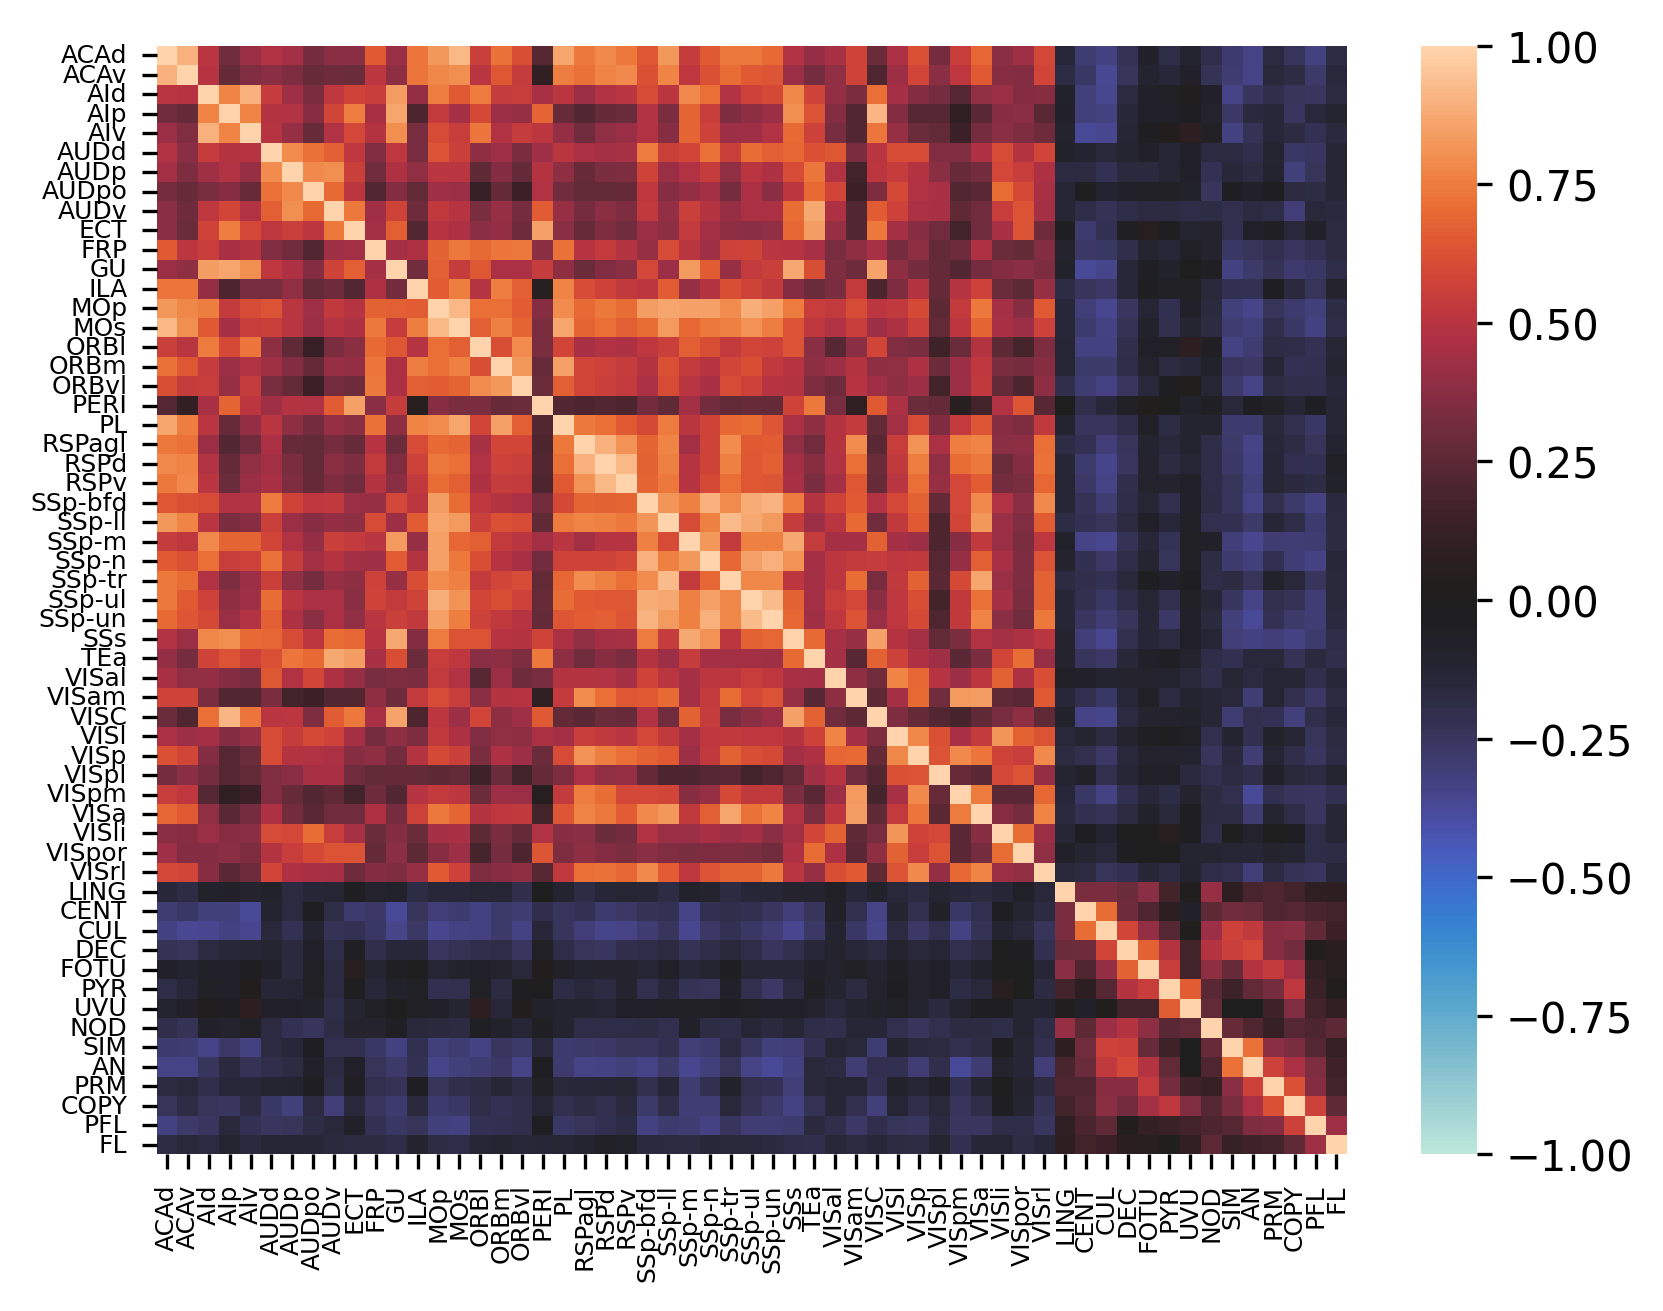

In [68]:
corrMatrix = dfCbOrCtxProj.corr(method = "spearman")
# mask = np.triu(np.ones_like(corrMatrix, dtype=bool), k=1)
plt.figure(dpi=300)
sns.heatmap(corrMatrix, xticklabels=True,yticklabels=True,  annot=False, fmt = '.2f', annot_kws={'size': 4}, cmap = 'icefire', vmin = -1, vmax = 1, center = 0)
plt.yticks(fontsize=6);
plt.xticks(fontsize=6);
plt.savefig(f"../results/Cortical and cerebellar correlation matrix (spearman, granular, projecting neurons).svg",dpi=300,bbox_inches='tight',transparent=True)

In [104]:
cbRois = ["LING","CENT","CUL","DEC","FOTU","PYR","UVU","NOD","SIM","AN","PRM","COPY","PFL","FL"]
cbAndCtxRois = list(bf_right_boundaries.keys()) + cbRois

# Convert to dataframe
dfLengths = pd.DataFrame.from_dict(lengthDict, orient='index').fillna(0)
dfLengths.rename(columns={'NaN': 'Other'}, inplace=True) # Rename "NaN" to "Other"
# Get just cortical areas
dfLengths = dfLengths[cbAndCtxRois] # Reorder the DataFrame based on sorted column names
dfCbAndCtxProj = dfLengths[(dfLengths[cbRois].sum(axis=1) > 0) & (dfLengths[bf_right_boundaries.keys()].sum(axis=1) > 0 )]
dfCbAndCtxProj.head(3)

,ACAd,ACAv,AId,AIp,AIv,AUDd,AUDp,AUDpo,AUDv,ECT,...,FOTU,PYR,UVU,NOD,SIM,AN,PRM,COPY,PFL,FL
N041-685221,2777.031684,3062.004709,2064.857461,3654.315874,907.793484,407.663305,619.439564,1965.658777,0.000000,2462.397629,...,3775.984628,2464.69494,3501.817368,0.0,582.285322,7842.162984,6579.048374,5894.098102,0.0,0.0
N005-685221,16506.169724,1620.913589,515.464728,0.000000,658.856404,1731.505816,4118.726955,0.000000,3862.869391,1931.173585,...,0.000000,0.00000,0.000000,0.0,151.075496,0.000000,0.000000,0.000000,0.0,0.0
N049-685221,0.000000,0.000000,0.000000,23.184220,0.000000,375.572508,875.851670,103.624144,0.000000,0.000000,...,0.000000,0.00000,0.000000,0.0,8476.546758,0.000000,0.000000,0.000000,0.0,0.0


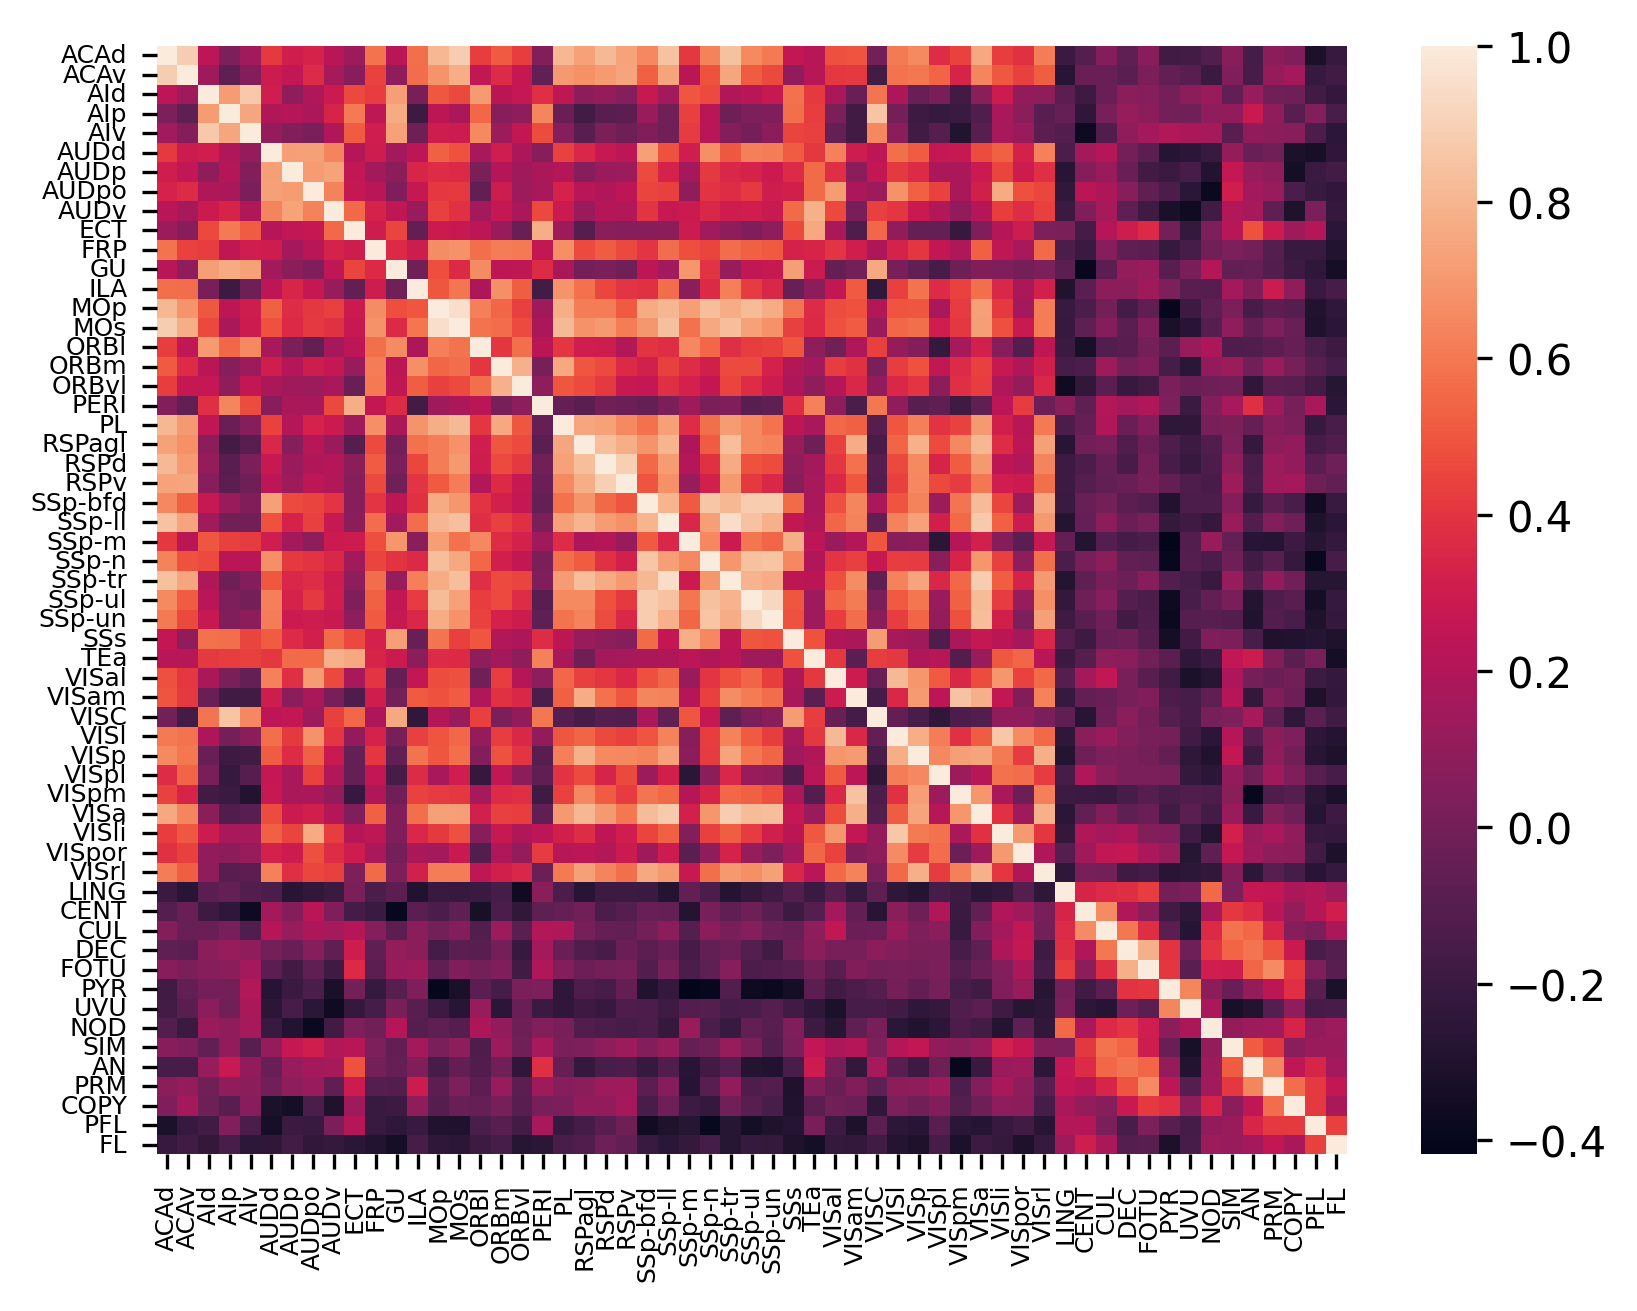

In [105]:
corrMatrix = dfCbAndCtxProj.corr(method = "spearman")
# mask = np.triu(np.ones_like(corrMatrix, dtype=bool), k=1)
plt.figure(dpi=300)
sns.heatmap(corrMatrix, xticklabels=True,yticklabels=True,  annot=False, fmt = '.2f', annot_kws={'size': 4})
plt.yticks(fontsize=6);
plt.xticks(fontsize=6);
plt.savefig(f"../results/Cortical and cerebellar correlation matrix (spearman, granular, projecting neurons).svg",dpi=300,bbox_inches='tight',transparent=True)